# Entropy vs. LLM-judge degeneration labels

This notebook first reproduces the entropy summaries from `inspect_dataset.ipynb`, then evaluates whether a persistent entropy drop can detect degeneration and locate its onset. The descriptive study uses every labeled rollout. The LLM-judge study uses the unified population shared with the TTR and LRS notebooks (`docs/analysis/metric_evaluation_unification_plan.md`): positives are judge-confirmed truncated rollouts, negatives are every natural-EOS rollout by definition plus the few judge-confirmed-negative truncated rollouts. Threshold calibration is separated from final evaluation by prompt. No dataset files are modified.


## 1. Definitions

For token-level entropy $H_t$, define the persistent drop at boundary $t$ using adjacent 64-token windows:

$$\Delta H_t = \operatorname{mean}(H_{t-64:t}) - \operatorname{mean}(H_{t:t+64}).$$

The entropy onset $o_H$ is the boundary with the largest drop, and $s_H=\max(0,\max_t \Delta H_t)$ is the completion-level score. For each dataset build, prompts are deterministically divided 50/50 into calibration and test sets. A threshold $\tau$ is selected only on calibration by maximizing balanced accuracy against `is_degenerating`; ties select the higher threshold. It is then applied unchanged to test.

**Population** (Section 4): positives are judge-confirmed truncated rollouts (`is_degenerating == True`); negatives are every `stop_reason == "eos"` rollout by definition (no judge call needed), plus the few judge-confirmed-negative truncated rollouts as hard negatives. This replaces an earlier version of this notebook, which built negatives from "historically judged natural-EOS rollouts" -- leftover judge verdicts from a now-removed sampling stratum -- and, because that stratum didn't exist for every build, excluded SFT-256k from the judge study entirely. All three dataset builds are evaluated below.

For a judge-positive rollout whose `onset_quote` is found in the generated tokens, signed onset distance is

$$d=o_{\mathrm{LLM}}-o_H.$$

Thus $d>0$ means the entropy rule fires earlier than the judge. Binary and onset results are reported only on test. Onset evaluation additionally requires a positive entropy prediction and a locatable judge quote, and (like the TTR and LRS notebooks) is computed on the truncated, judge-quote-matched population specifically -- natural-EOS rollouts are never judged, so they have no onset_quote to compare against.


In [1]:
import hashlib
import os
from pathlib import Path

SHARED_HF_CACHE = Path("/capstor/scratch/cscs/mdenegri/degeneration-probe/hf_cache")
if SHARED_HF_CACHE.exists():
    os.environ.setdefault("HF_HOME", str(SHARED_HF_CACHE))
    os.environ.setdefault("HF_HUB_CACHE", str(SHARED_HF_CACHE))
os.environ.setdefault("HF_HUB_OFFLINE", "1")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from transformers import AutoTokenizer

from degeneration_probe.analysis import metric_eval as metric_eval_module
from degeneration_probe.utils.tokenization import find_string_in_tokens

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 100)

DATA_ROOT = Path("/capstor/store/cscs/swissai/infra01/users/mdenegri/degeneration-probe")
DATASETS = {
    "Apertus-8B-Instruct": {
        "root": DATA_ROOT / "degeneration-dataset-apertus-8b-instruct",
        "tokenizer": "swiss-ai/Apertus-8B-Instruct-2509",
    },
    "Apertus 1.5 - capfilter-linear": {
        "root": DATA_ROOT / "degeneration-dataset-apertus1p5-capfilter-linear-it8816",
        "tokenizer": "/capstor/store/cscs/swissai/infra01/reasoning/models/tokenizers/apertus_emu3.5_wavtok_text_only",
    },
    "Apertus 1.5 - SFT-256k": {
        "root": DATA_ROOT / "degeneration-dataset-apertus1p5-sft256k-4200",
        "tokenizer": "/capstor/store/cscs/swissai/infra01/reasoning/models/tokenizers/apertus_emu3.5_wavtok_text_only",
    },
}
JUDGE_BACKEND = "claude_agent_sdk"
# Every build is now evaluated: the unified population's negatives (stop_reason=="eos")
# need no judge call, so the old "no historical natural-EOS rows for this build" exclusion
# (which used to drop SFT-256k) no longer applies.
EVALUATED_DATASETS = list(DATASETS)
WINDOW = 64
EXPECTED_MAX_TOKENS = 4096
KEY = ["prompt_id", "rollout_idx"]


W0722 10:34:28.015000 213557 torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


W0722 10:34:28.120000 213557 torch/utils/_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


## 2. Load all entropy labels

In [2]:
def read_domain_shards(root, kind, columns):
    frames = []
    for path in sorted((root / kind).glob("*/shard_*.parquet")):
        frame = pd.read_parquet(path, columns=columns)
        frame["domain"] = path.parent.name
        frames.append(frame)
    if not frames:
        raise FileNotFoundError(f"No {kind} shards found below {root}")
    result = pd.concat(frames, ignore_index=True)
    assert not result.duplicated(KEY).any(), f"Duplicate keys in {kind} shards"
    return result


all_labels = {}
for model, spec in DATASETS.items():
    labels = read_domain_shards(spec["root"], "labels", KEY + ["entropy"])
    labels["mean_entropy"] = labels["entropy"].apply(
        lambda values: float(np.mean(np.asarray(values, dtype=float)))
    )
    all_labels[model] = labels
    print(f"{model}: {len(labels):,} labeled rollouts")

Apertus-8B-Instruct: 36,300 labeled rollouts


Apertus 1.5 - capfilter-linear: 36,300 labeled rollouts


Apertus 1.5 - SFT-256k: 36,300 labeled rollouts


## 3. Descriptive entropy results

The tables below reproduce the `inspect_dataset.ipynb` aggregation: first compute mean entropy per rollout, then report its mean, maximum, and minimum within each domain. The boxplots add a compact view of the full per-rollout distributions.

[Apertus-8B-Instruct]


,mean,max,min
domain,,,
aime_2025,0.427700,0.966822,0.016300
codeforces,0.358503,1.004798,0.009439
deepmath_103k,0.414214,1.317496,0.012662
if_sft_data_verified,0.617717,4.593693,0.004877
llama_nemotron,0.435042,1.097740,0.006070
medical_o1,0.818040,1.641292,0.073178
numinamath_1_5,0.373331,1.347791,0.006872


[Apertus 1.5 - capfilter-linear]


,mean,max,min
domain,,,
aime_2025,0.174721,0.491418,0.031722
codeforces,0.251631,0.690874,0.009281
deepmath_103k,0.270388,1.045154,0.030188
if_sft_data_verified,0.621972,4.356446,0.002772
llama_nemotron,0.256914,1.077006,0.010899
medical_o1,0.564922,3.253996,0.018185
numinamath_1_5,0.330944,1.866546,0.007937


[Apertus 1.5 - SFT-256k]


,mean,max,min
domain,,,
aime_2025,0.260344,1.007261,0.032535
codeforces,0.256781,0.752959,0.009742
deepmath_103k,0.350859,1.836448,0.019784
if_sft_data_verified,0.643011,4.966056,0.001506
llama_nemotron,0.248608,0.799281,0.016623
medical_o1,0.924167,3.539158,0.017115
numinamath_1_5,0.316581,1.970370,0.013782


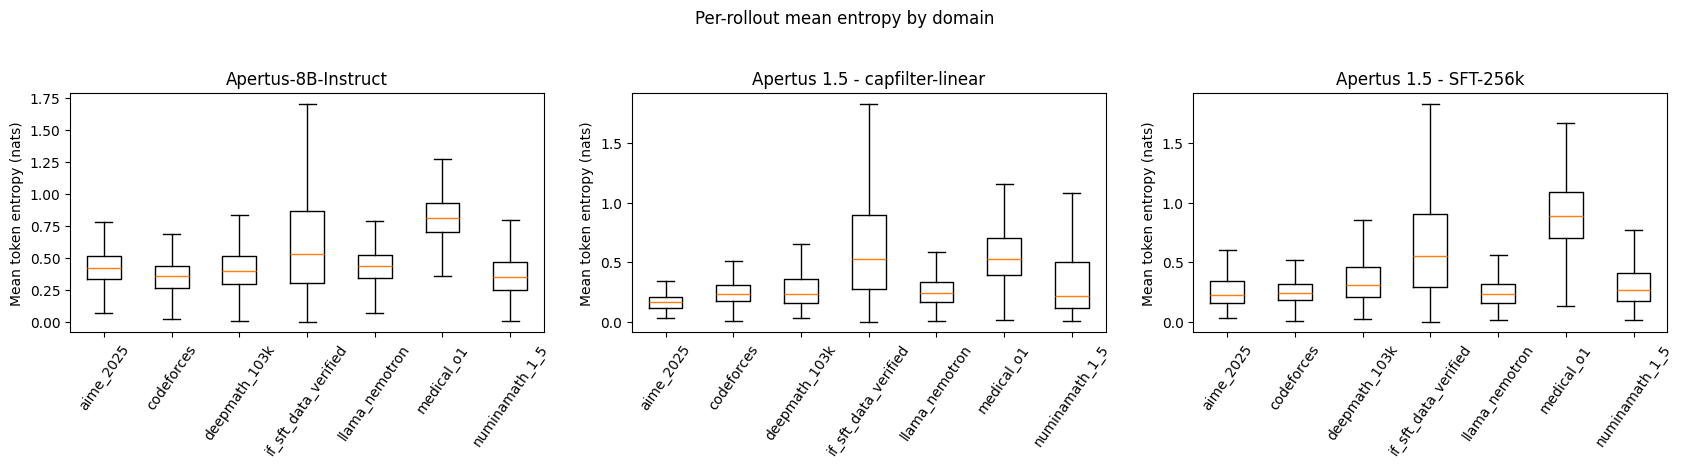

In [3]:
entropy_summary_frames = []
for model, labels in all_labels.items():
    summary = labels.groupby("domain")["mean_entropy"].agg(mean="mean", max="max", min="min")
    summary.insert(0, "dataset_build", model)
    entropy_summary_frames.append(summary.reset_index())
    print(f"[{model}]")
    display(summary.drop(columns="dataset_build"))

entropy_summary_df = pd.concat(entropy_summary_frames, ignore_index=True)

fig, axes = plt.subplots(1, len(DATASETS), figsize=(17, 4.5), sharey=False)
for ax, (model, labels) in zip(axes, all_labels.items()):
    domains = sorted(labels["domain"].unique())
    values = [labels.loc[labels["domain"].eq(domain), "mean_entropy"] for domain in domains]
    ax.boxplot(values, tick_labels=domains, showfliers=False)
    ax.set_title(model)
    ax.set_ylabel("Mean token entropy (nats)")
    ax.tick_params(axis="x", rotation=55)
fig.suptitle("Per-rollout mean entropy by domain", y=1.03)
fig.tight_layout()
plt.show()

## 4. Calibration and test LLM-judge populations

Two populations are built per dataset build:

- **`populations[model]`**: truncated rollouts only, joined with their successful judge verdict -- the same population as `ttr_inspection.ipynb` / `inspect_dataset.ipynb`'s LRS cell. This carries `generated_token_ids`, needed to locate the judge's `onset_quote` (Section 7).
- **`unified_populations[model]`**: every rollout. Positives are the judge-confirmed subset of the truncated population above; negatives are every `stop_reason == "eos"` rollout by definition, plus the judge-confirmed-negative truncated rows as hard negatives. This is what Section 6's detection tables are computed on.

Rows shorter than 128 tokens are excluded from both (reported, never silently treated as negative): they cannot contain two complete 64-token windows, so `persistent_entropy_drop` has no defined onset for them. Prompts are assigned deterministically and exclusively to calibration or test (`metric_eval.prompt_split`, shared with the TTR and LRS notebooks).


In [4]:
def prompt_split(prompt_id):
    digest = hashlib.sha256(f"entropy-inspection-v1:{prompt_id}".encode()).digest()
    return "test" if int.from_bytes(digest[:8], "big") < 2**63 else "calibration"


def load_raw_judge_frames(root):
    sample = pd.read_parquet(root / "llm_judge/calibration_sample.parquet")
    judge = pd.read_parquet(root / f"llm_judge/results_{JUDGE_BACKEND}.parquet")
    return sample, judge


def load_truncated_population(model, spec):
    """Truncated rollouts with a successful judge verdict, plus generated_token_ids
    for onset-quote localization (Section 7)."""
    root = spec["root"]
    sample_df, judge_df = load_raw_judge_frames(root)
    judge_ok = judge_df[judge_df["status"].eq("ok")][KEY + ["is_degenerating", "onset_quote", "confidence"]]
    population = sample_df.merge(judge_ok, on=KEY, how="inner", validate="one_to_one")

    generations = read_domain_shards(
        root, "generations", KEY + ["generated_token_ids", "num_tokens", "stop_reason"],
    )
    population = population.merge(
        generations[KEY + ["generated_token_ids", "num_tokens", "stop_reason"]],
        on=KEY, how="left", validate="one_to_one",
    ).merge(all_labels[model][KEY + ["entropy"]], on=KEY, how="left", validate="one_to_one")

    assert population["stop_reason"].eq("length").all(), "Sample contains a natural EOS rollout"
    assert all(len(ids) == len(entropy) == n for ids, entropy, n in zip(
        population["generated_token_ids"], population["entropy"], population["num_tokens"]
    )), "Token IDs and entropy are not aligned"

    population["is_degenerating"] = population["is_degenerating"].astype(bool)
    eligibility = {
        "dataset_build": model, "judge_ok_joined": len(population),
        "too_short_for_two_windows": int(population["num_tokens"].lt(2 * WINDOW).sum()),
    }
    population = population[population["num_tokens"].ge(2 * WINDOW)].copy()
    eligibility["entropy_eligible"] = len(population)
    population["evaluation_split"] = population["prompt_id"].apply(prompt_split)
    return population, eligibility


def load_full_entropy_population(root, model):
    """Every rollout (eos and length alike) with its entropy array -- the base
    for the unified population (every rollout, not just truncated ones)."""
    generations = read_domain_shards(root, "generations", KEY + ["num_tokens", "stop_reason"])
    population = generations.merge(all_labels[model][KEY + ["entropy"]], on=KEY, how="inner", validate="one_to_one")
    assert len(population) == len(generations), "Generation/entropy key mismatch"
    return population


populations = {}
full_populations = {}
unified_populations = {}
eligibility_rows = []
for model, spec in DATASETS.items():
    populations[model], eligibility = load_truncated_population(model, spec)
    eligibility_rows.append(eligibility)

    full_populations[model] = load_full_entropy_population(spec["root"], model)
    sample_df, judge_df = load_raw_judge_frames(spec["root"])
    unified = metric_eval_module.build_unified_population(full_populations[model], sample_df, judge_df, backend=None)
    unified = unified.merge(full_populations[model][KEY + ["entropy", "num_tokens"]], on=KEY, how="left")
    n_before = len(unified)
    unified = unified[unified["num_tokens"].ge(2 * WINDOW)].copy()
    print(f"{model}: {n_before - len(unified)} rows excluded as too short for two {WINDOW}-token windows")
    unified_populations[model] = unified

eligibility_df = pd.DataFrame(eligibility_rows).set_index("dataset_build")
display(eligibility_df)

composition_df = pd.concat([
    unified.groupby(["evaluation_split", "population", "is_positive"]).size().rename("n").reset_index().assign(dataset_build=model)
    for model, unified in unified_populations.items()
], ignore_index=True)
display(composition_df.pivot_table(
    index=["dataset_build", "evaluation_split", "population"],
    columns="is_positive", values="n", fill_value=0,
).rename(columns={False: "negative", True: "positive"}))


Apertus-8B-Instruct: 4536 rows excluded as too short for two 64-token windows


Apertus 1.5 - capfilter-linear: 5985 rows excluded as too short for two 64-token windows


Apertus 1.5 - SFT-256k: 6793 rows excluded as too short for two 64-token windows


,judge_ok_joined,too_short_for_two_windows,entropy_eligible
dataset_build,,,
Apertus-8B-Instruct,827,0,827
Apertus 1.5 - capfilter-linear,1278,0,1278
Apertus 1.5 - SFT-256k,1111,0,1111


is_positive                                                       negative  \
dataset_build                  evaluation_split population                   
Apertus 1.5 - SFT-256k         calibration      eos_negative       14727.0   
                                                truncated_judged      45.0   
                               test             eos_negative       13587.0   
                                                truncated_judged      33.0   
Apertus 1.5 - capfilter-linear calibration      eos_negative       15135.0   
                                                truncated_judged       4.0   
                               test             eos_negative       13832.0   
                                                truncated_judged       2.0   
Apertus-8B-Instruct            calibration      eos_negative       15951.0   
                                                truncated_judged       5.0   
                               test             eos_negative       14923.0   
                                                truncated_judged       3.0   

is_positive                                                       positive  
dataset_build                  evaluation_split population                  
Apertus 1.5 - SFT-256k         calibration      eos_negative           0.0  
                                                truncated_judged     551.0  
                               test             eos_negative           0.0  
                                                truncated_judged     482.0  
Apertus 1.5 - capfilter-linear calibration      eos_negative           0.0  
                                                truncated_judged     692.0  
                               test             eos_negative           0.0  
                                                truncated_judged     580.0  
Apertus-8B-Instruct            calibration      eos_negative           0.0  
                                                truncated_judged     428.0  
                               test             eos_negative           0.0  
                                                truncated_judged     391.0

## 5. Persistent entropy-drop rule

In [5]:
def persistent_entropy_drop(entropy, window=WINDOW):
    values = np.asarray(entropy, dtype=float)
    if len(values) < 2 * window or not np.isfinite(values).all():
        return np.nan, np.nan
    cumulative = np.concatenate(([0.0], np.cumsum(values)))
    boundaries = np.arange(window, len(values) - window + 1)
    before = (cumulative[boundaries] - cumulative[boundaries - window]) / window
    after = (cumulative[boundaries + window] - cumulative[boundaries]) / window
    drops = before - after
    best = int(np.argmax(drops))
    return int(boundaries[best]), float(max(0.0, drops[best]))


# Deterministic checks: no drop, a known step, and insufficient context.
onset, score = persistent_entropy_drop(np.ones(256))
assert onset == WINDOW and score == 0.0
step = np.r_[np.ones(128), np.zeros(128)]
assert persistent_entropy_drop(step) == (128, 1.0)
assert all(np.isnan(x) for x in persistent_entropy_drop(np.ones(100)))

for model, population in populations.items():
    estimates = population["entropy"].apply(persistent_entropy_drop)
    population[["entropy_onset", "entropy_drop_score"]] = pd.DataFrame(
        estimates.tolist(), index=population.index
    )
    assert population[["entropy_onset", "entropy_drop_score"]].notna().all().all()

for model, unified in unified_populations.items():
    estimates = unified["entropy"].apply(persistent_entropy_drop)
    unified[["entropy_onset", "entropy_drop_score"]] = pd.DataFrame(estimates.tolist(), index=unified.index)
    assert unified[["entropy_onset", "entropy_drop_score"]].notna().all().all()


## 6. Binary detection

Entropy is the prediction and the LLM judge is the reference. Each model-specific threshold is selected on calibration (`unified_populations`) by maximizing balanced accuracy, then applied unchanged to test. Aggregate, per-domain, and threshold-free ROC/PR results below are all computed on the test split of the unified population; domains below `metric_eval.MIN_POSITIVES_TEST` positive test rollouts are shown but excluded from the macro-average, same convention as the TTR and LRS notebooks.


Apertus-8B-Instruct: tuned threshold (calibration only) = 0.4835


,precision,recall,specificity,balanced_accuracy,mcc,accuracy,n_domains,n,tp,fp,fn,tn
ALL domains (macro-average),0.061127,0.731341,0.528844,0.630093,0.103227,0.534769,4.0,10437.0,NaN,NaN,NaN,NaN
ALL domains (pooled),0.040511,0.713555,0.557283,0.635419,0.085870,0.561272,NaN,15317.0,279.0,6608.0,112.0,8318.0
ALL domains (always predict positive),0.025527,1.000000,0.000000,0.500000,NaN,0.025527,NaN,15317.0,391.0,14926.0,0.0,0.0


Apertus 1.5 - capfilter-linear: tuned threshold (calibration only) = 0.4505


,precision,recall,specificity,balanced_accuracy,mcc,accuracy,n_domains,n,tp,fp,fn,tn
ALL domains (macro-average),0.108552,0.623245,0.716967,0.670106,0.162136,0.717948,5.0,12580.0,NaN,NaN,NaN,NaN
ALL domains (pooled),0.079284,0.694828,0.661703,0.678265,0.146643,0.663036,NaN,14414.0,403.0,4680.0,177.0,9154.0
ALL domains (always predict positive),0.040239,1.000000,0.000000,0.500000,NaN,0.040239,NaN,14414.0,580.0,13834.0,0.0,0.0


Apertus 1.5 - SFT-256k: tuned threshold (calibration only) = 0.4837


,precision,recall,specificity,balanced_accuracy,mcc,accuracy,n_domains,n,tp,fp,fn,tn
ALL domains (macro-average),0.085107,0.639918,0.737263,0.688591,0.156248,0.735854,6.0,13942.0,NaN,NaN,NaN,NaN
ALL domains (pooled),0.084239,0.643154,0.752570,0.697862,0.163721,0.748830,NaN,14102.0,310.0,3370.0,172.0,10250.0
ALL domains (always predict positive),0.034180,1.000000,0.000000,0.500000,NaN,0.034180,NaN,14102.0,482.0,13620.0,0.0,0.0


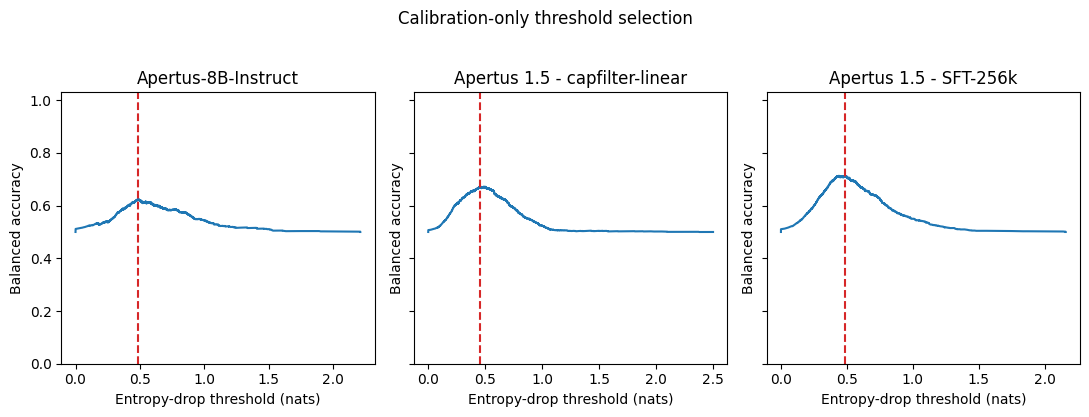

In [6]:
def select_balanced_accuracy_threshold(scores, truth):
    scores = np.asarray(scores, dtype=float)
    truth = np.asarray(truth, dtype=bool)
    unique = np.unique(scores)
    candidates = np.r_[np.nextafter(unique[0], -np.inf), unique, np.nextafter(unique[-1], np.inf)]
    rows = []
    for threshold in candidates:
        metrics = metric_eval_module.confusion_metrics(truth, scores >= threshold)
        rows.append({"threshold": threshold, **metrics})
    curve = pd.DataFrame(rows)
    best_score = curve["balanced_accuracy"].max()
    best = curve[curve["balanced_accuracy"].eq(best_score)].sort_values("threshold").iloc[-1]
    return float(best["threshold"]), curve


thresholds = {}
threshold_curves = {}
entropy_per_domain = {}
entropy_aggregate = {}
for model, unified in unified_populations.items():
    calibration = unified[unified["evaluation_split"].eq("calibration")]
    test = unified[unified["evaluation_split"].eq("test")].copy()

    threshold, curve = select_balanced_accuracy_threshold(
        calibration["entropy_drop_score"], calibration["is_positive"]
    )
    thresholds[model] = threshold
    threshold_curves[model] = curve
    populations[model]["entropy_flag"] = populations[model]["entropy_drop_score"].ge(threshold)
    test["entropy_flag"] = test["entropy_drop_score"].ge(threshold)

    per_domain = metric_eval_module.per_domain_table(test["is_positive"], test["entropy_flag"], test["domain"])
    macro = metric_eval_module.macro_average_row(per_domain).rename("ALL domains (macro-average)")
    pooled = pd.Series(
        metric_eval_module.pooled_row(test["is_positive"], test["entropy_flag"]), name="ALL domains (pooled)"
    )
    all_positive = pd.Series(
        metric_eval_module.confusion_metrics(test["is_positive"], np.ones(len(test), dtype=bool)),
        name="ALL domains (always predict positive)",
    )
    entropy_per_domain[model] = per_domain
    entropy_aggregate[model] = pd.DataFrame([macro, pooled, all_positive])

    print(f"{model}: tuned threshold (calibration only) = {threshold:.4f}")
    display(entropy_aggregate[model])

binary_metrics_df = pd.concat(
    {model: agg.loc["ALL domains (pooled)"] for model, agg in entropy_aggregate.items()}, axis=1
).T
binary_metrics_df.index.name = "dataset_build"

fig, axes = plt.subplots(1, len(EVALUATED_DATASETS), figsize=(11, 4), sharey=True)
for ax, (model, curve) in zip(axes, threshold_curves.items()):
    ax.plot(curve["threshold"], curve["balanced_accuracy"])
    ax.axvline(thresholds[model], color="tab:red", linestyle="--")
    ax.set_title(model)
    ax.set_xlabel("Entropy-drop threshold (nats)")
    ax.set_ylabel("Balanced accuracy")
    ax.set_ylim(0, 1.03)
fig.suptitle("Calibration-only threshold selection", y=1.03)
fig.tight_layout()
plt.show()


### 6.1 Per-domain results

`n`, TP/FP/FN/TN are shown alongside every metric, and the `insufficient` column marks domains below `metric_eval.MIN_POSITIVES_TEST` test-side positive rollouts -- excluded from the macro-average above, not silently hidden here.


In [7]:
for model, per_domain in entropy_per_domain.items():
    print(model)
    display(per_domain)


Apertus-8B-Instruct


,n,tp,fp,fn,tn,precision,recall,specificity,balanced_accuracy,mcc,accuracy,insufficient
domain,,,,,,,,,,,,
aime_2025,160,6,103,2,49,0.055046,0.750000,0.322368,0.536184,0.033847,0.343750,True
codeforces,2753,5,1220,2,1526,0.004082,0.714286,0.555717,0.635002,0.027361,0.556121,True
deepmath_103k,2602,40,1066,20,1476,0.036166,0.666667,0.580645,0.623656,0.075087,0.582629,False
if_sft_data_verified,2038,104,790,31,1113,0.116331,0.770370,0.584866,0.677618,0.178042,0.597154,False
llama_nemotron,2966,62,2057,3,844,0.029259,0.953846,0.290934,0.622390,0.079341,0.305462,False
medical_o1,1967,0,446,0,1521,0.000000,NaN,0.773259,0.773259,NaN,0.773259,True
numinamath_1_5,2831,62,926,54,1789,0.062753,0.534483,0.658932,0.596707,0.080438,0.653833,False


Apertus 1.5 - capfilter-linear


,n,tp,fp,fn,tn,precision,recall,specificity,balanced_accuracy,mcc,accuracy,insufficient
domain,,,,,,,,,,,,
aime_2025,160,2,29,7,122,0.064516,0.222222,0.807947,0.515085,0.017587,0.775000,True
codeforces,2726,29,689,12,1996,0.040390,0.707317,0.743389,0.725353,0.124541,0.742847,False
deepmath_103k,2770,8,708,30,2024,0.011173,0.210526,0.740849,0.475688,-0.012919,0.733574,False
if_sft_data_verified,1841,174,604,33,1030,0.223650,0.840580,0.630355,0.735467,0.301173,0.653992,False
llama_nemotron,2884,45,831,18,1990,0.051370,0.714286,0.705424,0.709855,0.133409,0.705617,False
medical_o1,1674,6,1315,0,353,0.004542,1.000000,0.211631,0.605815,0.031004,0.214456,True
numinamath_1_5,2359,139,504,77,1639,0.216174,0.643519,0.764816,0.704167,0.264478,0.753709,False


Apertus 1.5 - SFT-256k


,n,tp,fp,fn,tn,precision,recall,specificity,balanced_accuracy,mcc,accuracy,insufficient
domain,,,,,,,,,,,,
aime_2025,160,2,38,6,114,0.050000,0.250000,0.750000,0.500000,0.000000,0.725000,True
codeforces,2760,35,572,18,2135,0.057661,0.660377,0.788696,0.724537,0.148793,0.786232,False
deepmath_103k,2652,26,625,40,1961,0.039939,0.393939,0.758314,0.576127,0.055111,0.749246,False
if_sft_data_verified,1940,95,683,36,1126,0.122108,0.725191,0.622443,0.673817,0.177985,0.629381,False
llama_nemotron,2888,33,515,17,2323,0.060219,0.660000,0.818534,0.739267,0.159186,0.815789,False
medical_o1,815,33,240,12,530,0.120879,0.733333,0.688312,0.710823,0.204041,0.690798,False
numinamath_1_5,2887,86,697,43,2061,0.109834,0.666667,0.747281,0.706974,0.192368,0.743679,False


### 6.2 Threshold-free ROC/PR

As a sanity check that the calibrated threshold above wasn't a lucky pick, this sweeps every possible cutoff of `entropy_drop_score` and reports the resulting ROC/PR curves and AUC/average-precision, computed on the test split only.


Apertus-8B-Instruct: ROC AUC = 0.695, average precision = 0.072


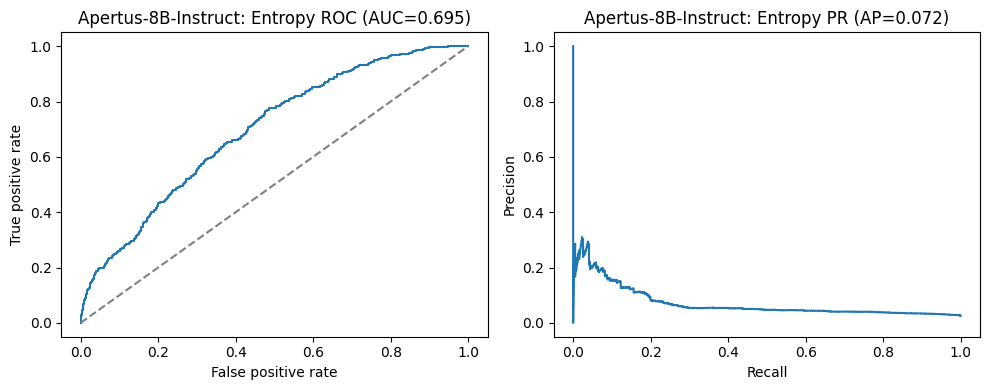

Apertus 1.5 - capfilter-linear: ROC AUC = 0.732, average precision = 0.086


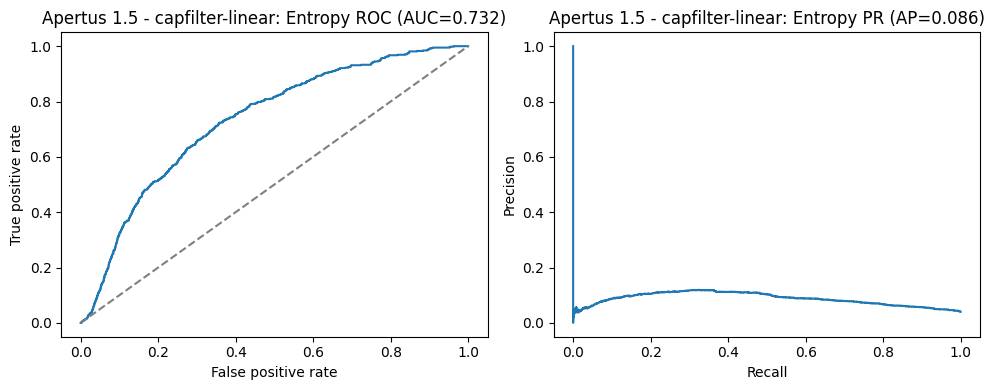

Apertus 1.5 - SFT-256k: ROC AUC = 0.776, average precision = 0.166


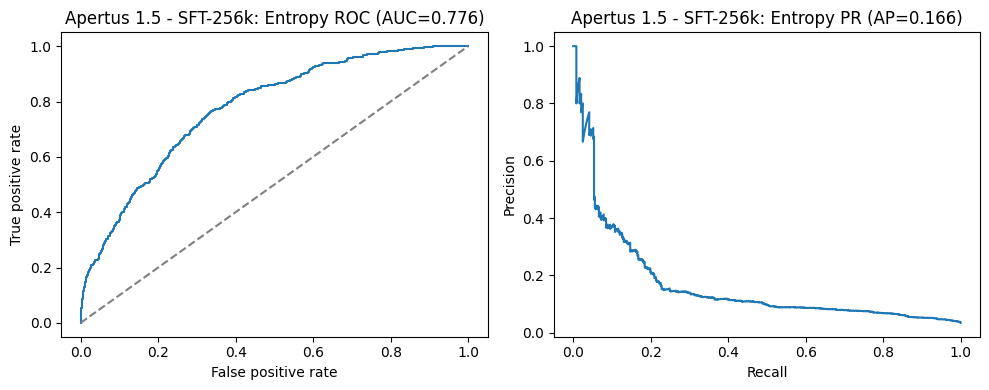

In [8]:
for model, unified in unified_populations.items():
    test = unified[unified["evaluation_split"].eq("test")]
    curve = metric_eval_module.roc_pr_curve(test["entropy_drop_score"], test["is_positive"])
    print(f"{model}: ROC AUC = {curve['roc_auc']:.3f}, average precision = {curve['average_precision']:.3f}")

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(curve["roc"]["fpr"], curve["roc"]["tpr"])
    axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
    axes[0].set_xlabel("False positive rate")
    axes[0].set_ylabel("True positive rate")
    axes[0].set_title(f"{model}: Entropy ROC (AUC={curve['roc_auc']:.3f})")

    axes[1].plot(curve["pr"]["recall"], curve["pr"]["precision"])
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_title(f"{model}: Entropy PR (AP={curve['average_precision']:.3f})")

    plt.tight_layout()
    plt.show()


## 7. Signed onset distance

Only test rows are used. Judge-positive rows with missing or unlocatable quotes are reported as coverage loss, not converted into negatives. Judge-positive/entropy-negative rows remain false negatives in Section 6 but cannot contribute a finite onset distance.

In [9]:
_tokenizer_cache = {}


def get_tokenizer(name):
    if name not in _tokenizer_cache:
        kwargs = {"local_files_only": True}
        if not Path(name).exists() and SHARED_HF_CACHE.exists():
            kwargs["cache_dir"] = str(SHARED_HF_CACHE)
        _tokenizer_cache[name] = AutoTokenizer.from_pretrained(name, **kwargs)
    return _tokenizer_cache[name]


def safe_ratio(numerator, denominator):
    return numerator / denominator if denominator else np.nan


def locate_onset_quote(quote, generated_token_ids, tokenizer):
    if not isinstance(quote, str) or not quote:
        return np.nan
    tokens = torch.as_tensor([int(token) for token in generated_token_ids])
    try:
        return int(find_string_in_tokens(quote, tokens, tokenizer).start)
    except (AssertionError, ValueError):
        return np.nan


quote_coverage_rows = []
for model, population in populations.items():
    tokenizer = get_tokenizer(DATASETS[model]["tokenizer"])
    positive = population["evaluation_split"].eq("test") & population["is_degenerating"]
    population["llm_onset"] = np.nan
    population.loc[positive, "llm_onset"] = [
        locate_onset_quote(quote, ids, tokenizer)
        for quote, ids in zip(
            population.loc[positive, "onset_quote"],
            population.loc[positive, "generated_token_ids"],
        )
    ]
    n_positive = int(positive.sum())
    n_matched = int(population.loc[positive, "llm_onset"].notna().sum())
    quote_coverage_rows.append({
        "dataset_build": model, "judge_positive": n_positive,
        "quote_present": int(population.loc[positive, "onset_quote"].notna().sum()),
        "quote_matched": n_matched,
        "match_rate_among_judge_positive": safe_ratio(n_matched, n_positive),
    })
quote_coverage_df = pd.DataFrame(quote_coverage_rows).set_index("dataset_build")
display(quote_coverage_df.style.format({"match_rate_among_judge_positive": "{:.1%}"}))


,judge_positive,quote_present,quote_matched,match_rate_among_judge_positive
dataset_build,,,,
Apertus-8B-Instruct,391,391,391,100.0%
Apertus 1.5 - capfilter-linear,580,580,578,99.7%
Apertus 1.5 - SFT-256k,482,482,482,100.0%


,n_comparable,mean_signed_distance,median_signed_distance,mean_absolute_distance,median_absolute_distance,q25_signed,q75_signed
dataset_build,,,,,,,
Apertus-8B-Instruct,279,375.0,277.0,479.1,336.0,-22.5,709.0
Apertus 1.5 - capfilter-linear,401,325.8,140.0,368.7,162.0,-28.0,495.0
Apertus 1.5 - SFT-256k,310,325.3,126.0,635.2,260.0,-45.5,706.2


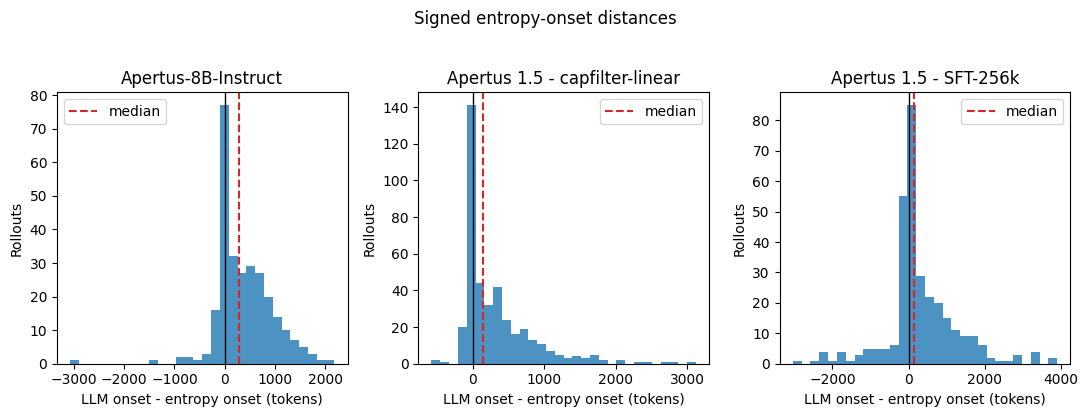

In [10]:
onset_frames = []
onset_rows = []
for model, population in populations.items():
    comparable = population[
        population["evaluation_split"].eq("test")
        & population["is_degenerating"]
        & population["entropy_flag"]
        & population["llm_onset"].notna()
    ].copy()
    comparable["signed_distance"] = comparable["llm_onset"] - comparable["entropy_onset"]
    comparable["absolute_distance"] = comparable["signed_distance"].abs()
    comparable["dataset_build"] = model
    onset_frames.append(comparable)
    signed = comparable["signed_distance"]
    absolute = comparable["absolute_distance"]
    onset_rows.append({
        "dataset_build": model, "n_comparable": len(comparable),
        "mean_signed_distance": signed.mean(),
        "median_signed_distance": signed.median(),
        "mean_absolute_distance": absolute.mean(),
        "median_absolute_distance": absolute.median(),
        "q25_signed": signed.quantile(0.25), "q75_signed": signed.quantile(0.75),
    })

onset_comparisons_df = pd.concat(onset_frames, ignore_index=True)
onset_summary_df = pd.DataFrame(onset_rows).set_index("dataset_build")
display(onset_summary_df.style.format({column: "{:.1f}" for column in onset_summary_df.columns if column != "n_comparable"}))

fig, axes = plt.subplots(1, len(EVALUATED_DATASETS), figsize=(11, 4), sharey=False)
for ax, model in zip(axes, EVALUATED_DATASETS):
    values = onset_comparisons_df.loc[onset_comparisons_df["dataset_build"].eq(model), "signed_distance"]
    ax.hist(values, bins=30, color="tab:blue", alpha=0.8)
    ax.axvline(0, color="black", linewidth=1)
    ax.axvline(values.median(), color="tab:red", linestyle="--", label="median")
    ax.set_title(model)
    ax.set_xlabel("LLM onset - entropy onset (tokens)")
    ax.set_ylabel("Rollouts")
    ax.legend()
fig.suptitle("Signed entropy-onset distances", y=1.03)
fig.tight_layout()
plt.show()

## 8. Interpretation notes

- Descriptive entropy tables (Section 3) and judge comparisons (Sections 4, 6, 7) use different populations: all labeled rollouts versus the unified judge population (positives from judge-confirmed truncated rollouts, negatives from every natural-EOS rollout plus the few judge-confirmed-negative truncated rows).
- Thresholds are selected on calibration prompts and evaluated once on disjoint test prompts. Balanced accuracy gives equal weight to sensitivity and specificity despite class imbalance.
- All three dataset builds are now evaluated (Section 6), including SFT-256k -- an earlier version of this notebook excluded it because it had no rows judged under a now-removed "historically flagged natural-EOS" sampling stratum; the unified population needs no judge call for negatives at all, so that exclusion no longer applies.
- Per-domain rows (Section 6.1) show `n`/TP/FP/FN/TN next to every metric and flag domains below `metric_eval.MIN_POSITIVES_TEST` positive test rollouts as `insufficient`; these are reported but excluded from the domain-balanced macro-average.
- The all-positive baseline remains visible because balanced accuracy and MCC can still be inflated or deflated by class prevalence alone.
- The entropy onset is the largest local 64-before/64-after mean drop. It need not correspond to low absolute entropy and can identify a task-related confidence transition unrelated to degeneration.
- Binary and onset tables have different denominators. Judge-positive/entropy-negative rows count as false negatives but have no entropy onset comparison; unlocatable judge quotes are also excluded only from onset statistics.
- Entropy remains a complementary exploratory signal: high agreement would support further validation, while low agreement would confirm that confidence alone is insufficient for degeneration labeling.
